In [105]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier
)
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error, mean_absolute_error, r2_score,
    roc_auc_score
)
from tensorflow.keras import layers, models

In [8]:
# Calculamos las métricas de evaluación
def calcular_metricas_evaluacion(y_prediccion: np.ndarray, y_real: np.ndarray, verbose: bool = True):
    """Calcula las métricas de evaluación para un modelo de regresión.
    
    Calcula cuatro métricas comunes para evaluar modelos de regresión: MSE (Error Cuadrático Medio),
    RMSE (Raíz del Error Cuadrático Medio), MAE (Error Absoluto Medio) y R² (Coeficiente de determinación).
    Opcionalmente imprime los resultados en un formato legible.
    
    Args:
        y_prediccion (np.ndarray): Valores predichos por el modelo.
        y_real (np.ndarray): Valores reales observados.
        verbose (bool, optional): Si es True, imprime las métricas calculadas. Por defecto es True.
    
    Returns:
        tuple[float, float, float, float]: Una tupla con cuatro valores en el siguiente orden:
            - mse: Error cuadrático medio.
            - rmse: Raíz del error cuadrático medio.
            - mae: Error absoluto medio.
            - r2: Coeficiente de determinación.
    
    Example:
        >>> mse, rmse, mae, r2 = calcular_metricas_evaluacion(modelo.predict(X_test), y_test)
        >>> print(f"R²: {r2:.4f}")
    """
    
    mse = mean_squared_error(y_real, y_prediccion)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_prediccion)
    r2 = r2_score(y_real, y_prediccion)

    if verbose:
        print("\nEvaluación del modelo:")
        print(f"MSE (Error cuadrático medio): {mse:.4f}")
        print(f"RMSE (Raíz del error cuadrático medio): {rmse:.4f}")
        print(f"MAE (Error absoluto medio): {mae:.4f}")
        print(f"R² (Coeficiente de determinación): {r2:.4f}")
        print(f"El modelo explica aproximadamente el {r2:.2%} de la varianza")
    
    return mse, rmse, mae, r2

In [111]:
df = pd.read_csv("../../data/processed/dataset_practica_final_preprocessed.csv")

df.isna().sum()

target_column = 'is_canceled'
    
# Eliminamos la columna is_canceled de las variables independientes
# Y transformamos a numérico la columna is_canceled
X_hotel = df.drop(columns=target_column)
y_hotel = df[target_column].astype(int)

# Hacemos un train-test split
X_train, X_test, y_train, y_test = train_test_split(X_hotel, y_hotel, test_size=0.2, random_state=42)

df.isna().sum()

lead_time                         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
booking_changes                   0
agent                             0
company                           0
adr                               0
hotel_city hotel                  0
hotel_resort hotel                0
market_segment_aviation           0
market_segment_complementary      0
market_segment_corporate          0
market_segment_direct             0
market_segment_groups             0
market_segment_offline ta/to      0
market_segment_online ta          0
market_segment_undefined          0
distribution_channel_corporate    0
distribution_channel_direct       0
distribution_channel_gds          0
distribution_channel_ta/to        0
distribution_channel_undefin

In [ ]:
# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'n_estimators': [50, 100, 200],
    'max_depth': [8, 12, 16, 25, 30, 35, 40, 45, 50]
}
modelo_rfc = RandomForestClassifier(random_state=42)
modelo_rfc_cv = GridSearchCV(modelo_rfc, dict_parametros, cv=3, scoring='accuracy', n_jobs=-1)
modelo_rfc_cv.fit(X_train, y_train)

# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_rfc_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rfc_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'max_depth': 30, 'n_estimators': 200}
Mejor score obtenido: 82.28%


In [106]:
# Inicializamos el modelo de Random Forest Classifier y lo entrenamos con los datos de entrenamiento
modelo_rfc = RandomForestClassifier(n_estimators=200, max_depth=30, random_state=42)
modelo_rfc.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_rfc.predict(X_test)
y_proba = modelo_rfc.predict_proba(X_test)[:, 1]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)

Accuracy:  0.83
Precisión: 0.83
Recall:    0.69
F1-Score:  0.75
AUC:       0.91


Evaluación del modelo:
MSE (Error cuadrático medio): 0.1708
RMSE (Raíz del error cuadrático medio): 0.4133
MAE (Error absoluto medio): 0.1708
R² (Coeficiente de determinación): 0.2717
El modelo explica aproximadamente el 27.17% de la varianza


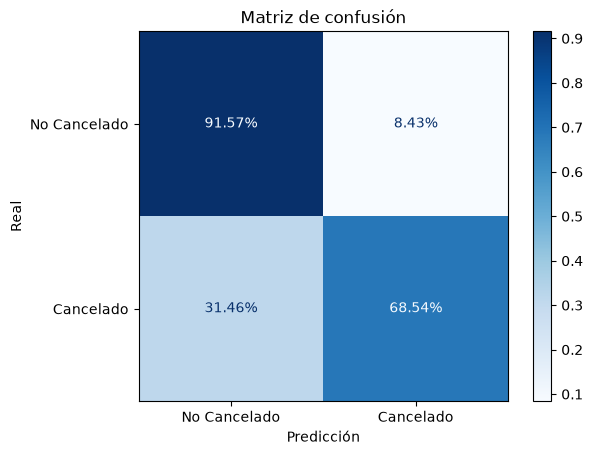

In [94]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado']
)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [ ]:
# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'max_depth': [8, 12, 16, 25, 30, 35, 40, 45, 50]
}
modelo_dt = DecisionTreeClassifier(random_state=42)
modelo_dt_cv = GridSearchCV(modelo_dt, dict_parametros, cv=3, scoring='accuracy', n_jobs=-1)
modelo_dt_cv.fit(X_train, y_train)

# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_dt_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_dt_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'max_depth': 16}
Mejor score obtenido: 79.33%


In [107]:
# Inicializamos el modelo de árbol de decisión y lo entrenamos con los datos de entrenamiento
modelo_dt = DecisionTreeClassifier(max_depth=16, random_state=42)
modelo_dt.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_dt.predict(X_test)
y_proba = modelo_dt.predict_proba(X_test)[:, 1]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)

Accuracy:  0.80
Precisión: 0.79
Recall:    0.64
F1-Score:  0.71
AUC:       0.87


Evaluación del modelo:
MSE (Error cuadrático medio): 0.1997
RMSE (Raíz del error cuadrático medio): 0.4469
MAE (Error absoluto medio): 0.1997
R² (Coeficiente de determinación): 0.1485
El modelo explica aproximadamente el 14.85% de la varianza


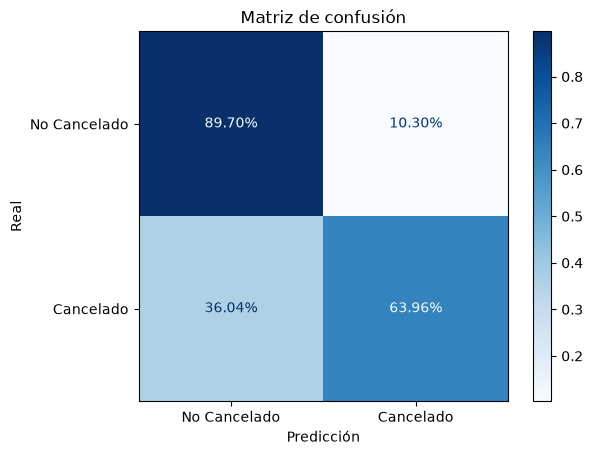

In [96]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado']
)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [ ]:
# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'C': [0.01, 0.1, 1],
    'max_iter' : [100, 200, 400, 500, 600, 700, 800, 900, 1000],
    'solver': ['liblinear']
}

modelo_rl = LogisticRegression(random_state=42)
modelo_rl_cv = GridSearchCV(modelo_rl, dict_parametros, cv=3, scoring='accuracy')
modelo_rl_cv.fit(X_train, y_train)

# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_rl_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_rl_cv.best_score_:.2%}")

Mejores hiperparámetros encontrados: {'C': 0.1, 'max_iter': 100, 'solver': 'liblinear'}
Mejor score obtenido: 77.82%


In [108]:
# Inicializamos el modelo de regresión logística y lo entrenamos con los datos de entrenamiento
modelo_lr = LogisticRegression(C=0.1, max_iter=100, random_state=42)
modelo_lr.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lr.predict(X_test)
y_proba = modelo_lr.predict_proba(X_test)[:, 1]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)

Accuracy:  0.78
Precisión: 0.89
Recall:    0.47
F1-Score:  0.61
AUC:       0.82


Evaluación del modelo:
MSE (Error cuadrático medio): 0.2216
RMSE (Raíz del error cuadrático medio): 0.4707
MAE (Error absoluto medio): 0.2216
R² (Coeficiente de determinación): 0.0553
El modelo explica aproximadamente el 5.53% de la varianza


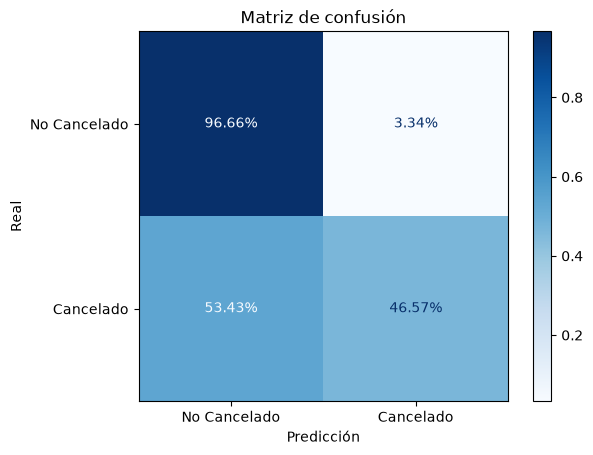

In [98]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado']
)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [60]:
# Entrenamos un modelo usando GridSearchCV para encontrar los mejores hiperparámetros
dict_parametros = {
    'n_estimators': [100, 200],
    'learning_rate': [0.03, 0.1],
    'max_depth': [6, 10],
    'num_leaves': [31, 63]
}

modelo_lgb = LGBMClassifier(random_state=42)
modelo_lgb_cv = GridSearchCV(modelo_lgb, dict_parametros, cv=3, scoring='accuracy')
modelo_lgb_cv.fit(X_train, y_train)

# Mostramos los mejores hiperparámetros encontrados
print(f"Mejores hiperparámetros encontrados: {modelo_lgb_cv.best_params_}")
print(f"Mejor score obtenido: {modelo_lgb_cv.best_score_:.2%}")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23502, number of negative: 40172
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004982 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1072
[LightGBM] [Info] Number of data points in the train set: 63674, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.369099 -> initscore=-0.536085
[LightGBM] [Info] Start training from score -0.536085
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 23502, number of negative: 40173
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003588 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_c

In [109]:
# Inicializamos el modelo de LGBMClassifier y lo entrenamos con los datos de entrenamiento
modelo_lgb = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=10, num_leaves=63, random_state=42)
modelo_lgb.fit(X_train, y_train)

# Hacemos predicciones sobre el conjunto de test
y_pred = modelo_lgb.predict(X_test)
y_proba = modelo_lgb.predict_proba(X_test)[:, 1]

# Obtención de las métricas de evaluación
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.2f}")
print(f"Precisión: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

mse, rmse, mae, r2 = calcular_metricas_evaluacion(y_pred, y_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 35253, number of negative: 60259
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005751 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1108
[LightGBM] [Info] Number of data points in the train set: 95512, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.369095 -> initscore=-0.536101
[LightGBM] [Info] Start training from score -0.536101
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

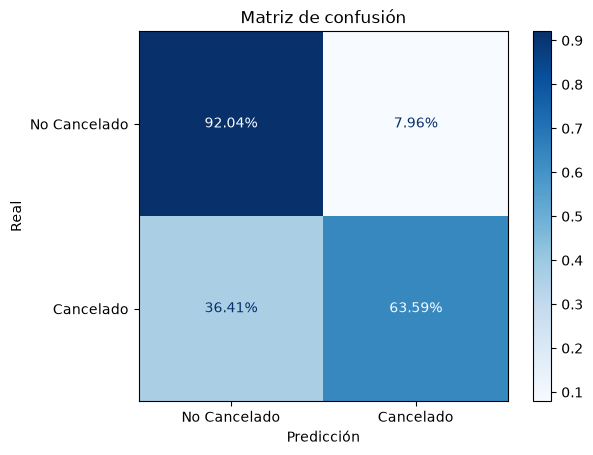

In [100]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado']
)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [77]:
# Definimos la arquitectura del modelo
modelo_dp = models.Sequential([
    layers.Input(shape=(X_train.shape[1], ), name='i1'),
    layers.Dense(128, activation='relu', name='h1'),
    layers.Dense(64, activation='relu', name='h2'),
    layers.Dense(32, activation='relu', name='h3'),
    layers.Dense(1, activation='sigmoid', name='o1')
])

# Compilamos el modelo
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
modelo_dp.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])

history_dp = modelo_dp.fit(X_train, y_train, epochs=150, validation_split=0.2, verbose=1)

y_pred_prob = modelo_dp.predict(X_test)

# Evaluamos el modelo en el conjunto de prueba
loss_dp, accuracy_dp = modelo_dp.evaluate(X_test, y_test)
print(f"Test Loss: {loss_dp:.4f}, Test Accuracy: {accuracy_dp:.4f}")

Epoch 1/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 3s 804us/step - accuracy: 0.7747 - loss: 0.4551 - val_accuracy: 0.7811 - val_loss: 0.4446
Epoch 2/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 530us/step - accuracy: 0.7839 - loss: 0.4346 - val_accuracy: 0.7773 - val_loss: 0.4419
Epoch 3/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 423us/step - accuracy: 0.7859 - loss: 0.4284 - val_accuracy: 0.7863 - val_loss: 0.4367
Epoch 4/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 452us/step - accuracy: 0.7879 - loss: 0.4238 - val_accuracy: 0.7845 - val_loss: 0.4332
Epoch 5/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 372us/step - accuracy: 0.7903 - loss: 0.4197 - val_accuracy: 0.7863 - val_loss: 0.4334
Epoch 6/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 396us/step - accuracy: 0.7899 - loss: 0.4164 - val_accuracy: 0.7866 - val_loss: 0.4307
Epoch 7/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 501us/step - accuracy: 0.7938 - loss: 0.4131 - val_accuracy: 0.7874 - val_loss: 0.4271
Epoch 8/150
2388/2388 ━━━━━━━━━━━━━━━━━━━━ 1s 390us/step - accuracy: 

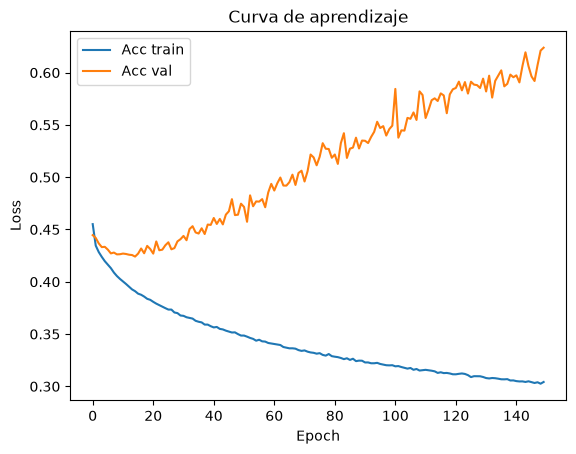

In [78]:
# Se muestra la función de coste del modelo
plt.plot(history_dp.history['loss'], label='Acc train')
plt.plot(history_dp.history['val_loss'], label='Acc val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Curva de aprendizaje')
plt.legend()
plt.show()

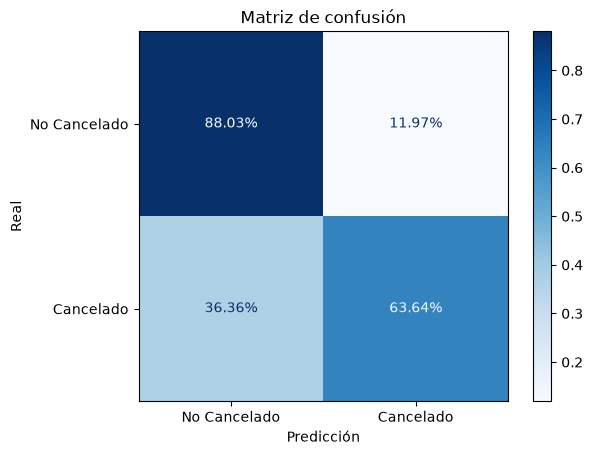

In [101]:
# Matriz de confusión
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm, display_labels=['No Cancelado', 'Cancelado']
)
disp.plot(cmap='Blues', values_format='.2%')
plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()